In [ ]:
import string
import requests
import re
import numpy as np

def get_data():
    resp = requests.get("https://www.gutenberg.org/files/35/35-0.txt")
    return resp.text

txt = get_data()


In [3]:
strings2replace = [
                 '\r\n\r\nâ\x80\x9c', # new paragraph
                 'â\x80\x9c',         # open quote
                 'â\x80\x9d',         # close quote
                 '\r\n',              # new line
                 'â\x80\x94',         # hyphen
                 'â\x80\x99',         # single apostrophe
                 'â\x80\x98',         # single quote
                 '_',                 # underscore, used for stressing
                 ]

for rpl in strings2replace:
    rexp = re.compile(r'%s'%rpl)
    rexp.sub(' ', txt)


# remove non-ASCII characters
txt = re.sub(r'[^\x00-\x7F]+', ' ', txt)

# remove numbers
txt = re.sub(r'\d+','',txt)

# and make everything lower-case
txt = txt.lower()

split_rexp = f"[{string.punctuation}\\s]+"
all_words = re.split(split_rexp, txt)
all_words[:3]


['', 'start', 'of']

In [7]:
# vocab
vocab = sorted(set(all_words))
print("All words ", len(all_words))
print("vocab ", len(vocab) )

All words  32909
vocab  4601


In [ ]:
# w2i,i2w dicts
w2i = {w:i for i,w in enumerate(vocab)}
i2w = {i:w for w,i in w2i.items()}

1

In [111]:
def encoder(words, w2i=w2i):
    return [w2i[word.lower()] for word in words]

def decoder(idxs, i2w=i2w):
    return " ".join([i2w[idx] for idx in idxs])

In [128]:
token_indexes = np.cumsum(np.random.choice([-1,1], 30)) + np.random.choice(len(vocab), 1)
print(token_indexes)
decoder(token_indexes)

[1534 1533 1534 1535 1536 1535 1534 1535 1536 1535 1536 1537 1536 1537
 1538 1539 1538 1537 1538 1537 1536 1535 1534 1535 1536 1535 1536 1535
 1534 1533]


'floated flitted floated flood floor flood floated flood floor flood floor flopping floor flopping floral flourish floral flopping floral flopping floor flood floated flood floor flood floor flood floated flitted'

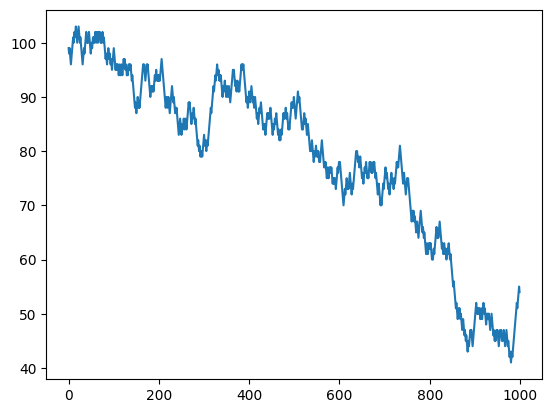

In [109]:
import matplotlib.pyplot as plt


bn = np.cumsum(np.random.choice([-1,1], 1000)) + 100

plt.plot(bn)
plt.show()